# Logistic Regression with Python

In this notebook we implement logistic regression for binary classification from scratch.
We introduce the binary cross-entropy (logistic) loss and derive the gradients used in gradient descent.

### Section 1: Binary classification (2D) - separable clusters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
plt.style.use("seaborn-v0_8")

## Generate a separable 2D dataset

We generate two Gaussian clusters in 2D (label 0 and 1) so that we can visualize the decision boundary.

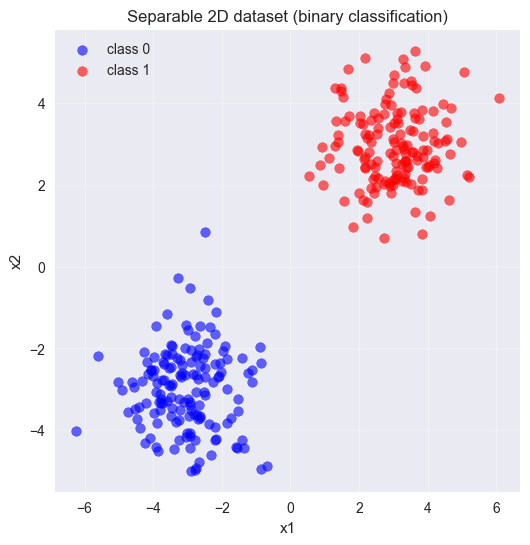

In [2]:
# Create two clearly separated clusters
X, y = make_blobs(n_samples=300, centers=[(-3, -3), (3, 3)], cluster_std=1.0, random_state=42)
# Plot the dataset
plt.figure(figsize=(6,6))
plt.scatter(X[y==0,0], X[y==0,1], color='blue', alpha=0.6, label='class 0')
plt.scatter(X[y==1,0], X[y==1,1], color='red', alpha=0.6, label='class 1')
plt.legend()
plt.title('Separable 2D dataset (binary classification)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
# Create a train/test split for evaluation (students can use X_train, X_test, y_train, y_test)
from sklearn.model_selection import train_test_split
# Stratify to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f'X_train.shape = {X_train.shape}, X_test.shape = {X_test.shape}')

X_train.shape = (210, 2), X_test.shape = (90, 2)


## Logistic model and binary cross-entropy (BCE) loss

Model (sigmoid logistic):

The model outputs a probability

$$
p\bigl(y=1\mid x;\boldsymbol{\beta}\bigr)=\sigma(z),\qquad z=\beta_0+\sum_{j=1}^d\beta_j x_j=\mathbf{x}_{\mathrm{design}}^\top\boldsymbol{\beta}
$$

where $\sigma(z)=\dfrac{1}{1+e^{-z}}$ is the sigmoid function and the design vector is $\mathbf{x}_{\mathrm{design}}=[1,x_1,\dots,x_d]^\top$ (leading 1 for the intercept).

Binary cross-entropy (average over the dataset):

$$
L(\boldsymbol{\beta})=-\frac{1}{N}\sum_{i=1}^N\left[ y_i\log p_i + (1-y_i)\log(1-p_i)\right],\qquad p_i=\sigma\bigl(\mathbf{x}_{i,\mathrm{design}}^\top\boldsymbol{\beta}\bigr)
$$

Vector form (useful for implementation):

$$
\mathbf{p}=\sigma\bigl(X_{\mathrm{design}}\boldsymbol{\beta}\bigr),\qquad L(\boldsymbol{\beta})=-\frac{1}{N}\left(\mathbf{y}^\top\log\mathbf{p} + (\mathbf{1}-\mathbf{y})^\top\log(\mathbf{1}-\mathbf{p})\right).
$$

Gradients (component-wise and vectorized): for each parameter $\beta_j$ (with $x_{i0}=1$ for the intercept)

$$
\frac{\partial L}{\partial \beta_j}=\frac{1}{N}\sum_{i=1}^N (p_i-y_i) x_{ij},
$$

$$
\nabla_{\boldsymbol{\beta}} L=\frac{1}{N}X_{\mathrm{design}}^\top(\mathbf{p}-\mathbf{y}).
$$

#### Notes:
- For numerical stability clip probabilities to $(\varepsilon,1-\varepsilon)$ before evaluating logarithms, or implement numerically stable log-sum-exp style computations.
- Use the vectorized gradient above to implement gradient descent updates: $\boldsymbol{\beta}\leftarrow\boldsymbol{\beta}-\alpha\nabla_{\boldsymbol{\beta}}L$.

Your task: implement the sigmoid, the BCE loss and the gradient (using these formulas) and then implement gradient descent to learn $\boldsymbol{\beta}$.

In [ ]:
def sigmoid(z):
    """
    Numerically stable sigmoid function.

    Parameters
    ----------
    z : array-like
        Input values.

    Returns
    -------
    s : ndarray
        Sigmoid applied elementwise.
    """
    z = np.asarray(z)
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    neg = ~pos
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    exp_z = np.exp(z[neg])
    out[neg] = exp_z / (1.0 + exp_z)
    return out


def compute_bce_loss(X_design, y, beta, eps=1e-15):
    """
    Compute average binary cross-entropy loss.

    Parameters
    ----------
    X_design : ndarray, shape (n_samples, n_features+1)
        Design matrix (including column of ones for intercept).
    y : ndarray, shape (n_samples,)
        Binary labels (0 or 1).
    beta : ndarray, shape (n_features+1,)
        Parameter vector (intercept first).

    Returns
    -------
    loss : float
        Average BCE loss.
    """
    X_design = np.asarray(X_design)
    y = np.asarray(y).ravel()
    beta = np.asarray(beta).ravel()
    p = sigmoid(X_design.dot(beta))
    p = np.clip(p, eps, 1 - eps)
    loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    return float(loss)


def gradients(X_design, y, beta):
    """
    Compute gradient of BCE loss w.r.t. beta (vectorized):

    grad = (1/N) * X_design^T (p - y)

    where p = sigmoid(X_design @ beta)
    """
    X_design = np.asarray(X_design)
    y = np.asarray(y).ravel()
    beta = np.asarray(beta).ravel()
    N = X_design.shape[0]
    p = sigmoid(X_design.dot(beta))
    grad = (X_design.T.dot(p - y)) / N
    return grad


def fit_logistic_regression_gd(X, y, learning_rate=0.1, n_steps=1000):
    """
    Fit logistic regression using gradient descent. X should NOT include intercept column.

    Parameters
    ----------
    X : ndarray, shape (n_samples, n_features)
    y : ndarray, shape (n_samples,)
    learning_rate : float
    n_steps : int

    Returns
    -------
    beta : ndarray, shape (n_features+1,)
        Learned parameters (intercept first).
    loss_history : list
        Recorded loss (every k iterations if desired).
    """
    X = np.asarray(X)
    y = np.asarray(y).ravel()
    N, d = X.shape
    X_design = np.hstack((np.ones((N, 1)), X))

    beta = np.zeros(d + 1, dtype=float)
    loss_history = []
    record_every = max(1, n_steps // 100)

    for i in range(n_steps):
        grad = gradients(X_design, y, beta)
        beta -= learning_rate * grad
        if (i % record_every) == 0:
            loss_history.append(compute_bce_loss(X_design, y, beta))

    return beta, loss_history

In [23]:
# Example usage (after implementing sigmoid and fitting beta):
n_iterations = 1000
beta, loss_hist = fit_logistic_regression_gd(X_train, y_train, learning_rate=0.3, n_steps=n_iterations)

test_accuracy = np.mean((sigmoid(np.hstack((np.ones((X_test.shape[0], 1)), X_test)).dot(beta)) >= 0.5) == y_test)
print(f'Test accuracy: {test_accuracy:.4f}')

Test accuracy: 1.0000


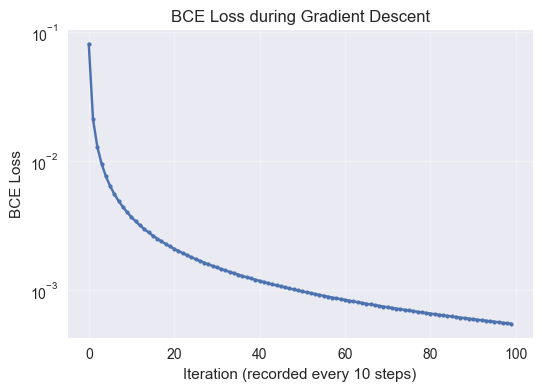

In [24]:
# Plot loss for different learning rates (students can experiment with this by changing the learning_rate parameter above)
plt.figure(figsize=(6,4))
plt.plot(loss_hist, markersize=3, marker='o')
plt.semilogy()  # Use logarithmic scale for better visibility of loss decrease
plt.title('BCE Loss during Gradient Descent')
plt.xlabel(f'Iteration (recorded every {max(1, n_iterations // 100)} steps)')
plt.ylabel('BCE Loss')
plt.grid(True, alpha=0.3)
plt.show()


Use the function bellow to visualize the decision regions according to your model. What can you say about the boundary between these regions?

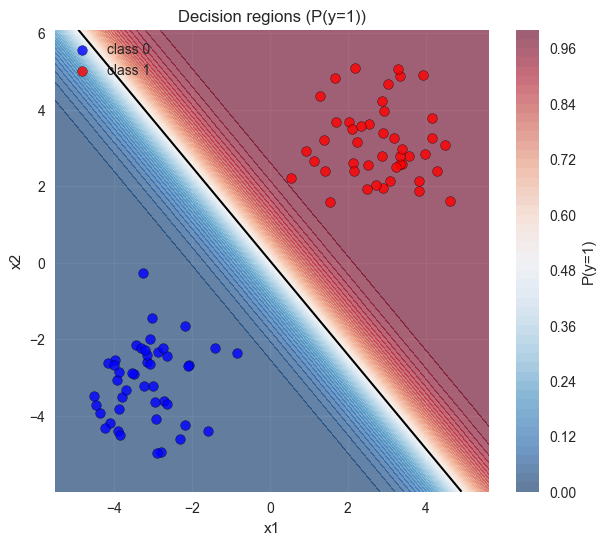

In [25]:
def plot_decision_regions(params, X, y, grid_res=200, cmap='RdBu_r', proba_contours=[0.5], ax=None, show_prob=True):
    """
    Plot decision regions and probability contours for a logistic regression model (2D inputs).

    This generalized function supports:
    - Binary classification: `params` is a 1D array (d+1,) representing beta (intercept first). In this
      case it shows the probability P(y=1) and optional probability contours.
    - Multiclass classification: `params` is a 2D array (d+1, K) representing the parameter matrix B.
      The function visualizes the predicted class regions (argmax) and shows a discrete colorbar.

    Parameters
    ----------
    params : array-like, shape (d+1,) or (d+1, K)
        Parameter vector (binary) or parameter matrix (multiclass) with intercept first.
    X : ndarray, shape (n_samples, 2)
        Input features (must be 2-dimensional for visualization).
    y : ndarray, shape (n_samples,)
        Labels (integers 0..K-1 for multiclass or 0/1 for binary).
    grid_res : int, default=200
        Resolution of the evaluation grid.
    cmap : str, default='RdBu'
        Colormap for probability field (binary) or base colormap for multiclass.
    proba_contours : list, default=[0.5]
        Probability levels to draw contour lines for (binary case only).
    ax : matplotlib.axes.Axes, optional
        Axes to draw on. If None, a new figure/axes will be created.
    show_prob : bool, default=True
        For binary case: show probability heatmap and contours. For multiclass: shows class regions (argmax).
    """

    from scipy.special import expit as _sigmoid
    from scipy.special import softmax as _softmax

    params = np.asarray(params)
    X = np.asarray(X)
    y = np.asarray(y).ravel()

    if X.ndim != 2 or X.shape[1] != 2:
        raise ValueError('plot_decision_regions supports only 2D input features (n_samples, 2)')

    d = X.shape[1]
    # Validate params shape
    if params.ndim == 1:
        if params.shape[0] != d + 1:
            raise ValueError('params must have shape (d+1,) for binary case')
        mode = 'binary'
    elif params.ndim == 2:
        if params.shape[0] != d + 1:
            raise ValueError('params must have shape (d+1, K) for multiclass case')
        mode = 'multiclass'
        K = params.shape[1]
    else:
        raise ValueError('params must be 1D (binary) or 2D (multiclass)')

    x_min, x_max = X[:,0].min() - 1.0, X[:,0].max() + 1.0
    y_min, y_max = X[:,1].min() - 1.0, X[:,1].max() + 1.0

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_res),
                          np.linspace(y_min, y_max, grid_res))
    grid = np.column_stack((xx.ravel(), yy.ravel()))
    X_design_grid = np.hstack(( np.ones((grid.shape[0],1)), grid ))

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7,6))
        created_fig = True

    if mode == 'binary':
        probs = _sigmoid(X_design_grid.dot(params))
        Z = probs.reshape(xx.shape)

        if show_prob:
            cf = ax.contourf(xx, yy, Z, levels=50, cmap=cmap, alpha=0.6)
            if proba_contours is not None and len(proba_contours) > 0:
                ax.contour(xx, yy, Z, levels=proba_contours, colors='k', linewidths=1.5)
            if created_fig:
                cbar = plt.colorbar(cf, ax=ax)
                cbar.set_label('P(y=1)')
        else:
            # Show decision boundary only
            Z_bin = (Z >= 0.5).astype(int)
            cf = ax.contourf(xx, yy, Z_bin, levels=[-0.5, 0.5, 1.5], cmap=cmap, alpha=0.3)

        # scatter the data
        ax.scatter(X[y==0,0], X[y==0,1], color='blue', edgecolor='k', label='class 0', alpha=0.8)
        ax.scatter(X[y==1,0], X[y==1,1], color='red', edgecolor='k', label='class 1', alpha=0.8)

        ax.set_title('Decision regions (P(y=1))')

    else:  # multiclass
        scores = X_design_grid.dot(params)  # (n_grid, K)
        P = _softmax(scores, axis=1)
        y_pred_grid = np.argmax(P, axis=1)
        Z = y_pred_grid.reshape(xx.shape)

        cmap_disc = plt.cm.get_cmap('tab10', K)
        cf = ax.contourf(xx, yy, Z, levels=np.arange(-0.5, K + 0.5, 1), cmap=cmap_disc, alpha=0.5)

        # plot training points colored by true class
        colors = [cmap_disc(i) for i in range(K)]
        for k in range(K):
            ax.scatter(X[y==k,0], X[y==k,1], color=colors[k], edgecolor='k', label=f'class {k}', alpha=0.85)

        ax.set_title('Decision regions (predicted class)')

        if created_fig:
            # discrete colorbar for classes
            cbar = plt.colorbar(cf, ax=ax, ticks=range(K))
            cbar.set_ticks(range(K))
            cbar.set_ticklabels([str(i) for i in range(K)])
            cbar.set_label('Predicted class')

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.legend()

    if created_fig:
        plt.show()



plot_decision_regions(beta, X_test, y_test)


## Generate and visualize a 3-class (3-blob) dataset

We create a synthetic 3-class dataset using `make_blobs` to visualize a multiclass classification scenario suitable for the softmax model. The variables `X_multi` and `y_multi` will be available for subsequent exercises.

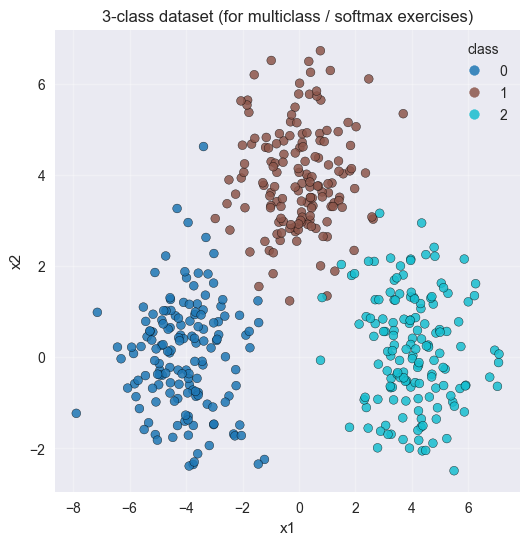

X_multi.shape = (450, 2) y_multi.shape = (450,)


In [26]:
# Use clear, separated centers to make the classes visually distinct
X_multi, y_multi = make_blobs(n_samples=450,
                              centers=[(-4, 0), (0, 4), (4, 0)],
                              cluster_std=1.2,
                              random_state=42)

plt.figure(figsize=(6,6))
sc = plt.scatter(X_multi[:,0], X_multi[:,1], c=y_multi, cmap='tab10', s=40, edgecolor='k', alpha=0.85)
plt.legend(*sc.legend_elements(), title='class')
plt.title('3-class dataset (for multiclass / softmax exercises)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True, alpha=0.3)
plt.show()

# Quick shape overview for students
print('X_multi.shape =', X_multi.shape, 'y_multi.shape =', y_multi.shape)

In [31]:
# Create a train/test split for evaluation (students can use X_multi_train, X_multi_test, y_multi_train, y_multi_test)
X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(X_multi, y_multi, test_size=0.3, random_state=42, stratify=y_multi)
print(f'X_multi_train.shape = {X_multi_train.shape}, X_multi_test.shape = {X_multi_test.shape}')

X_multi_train.shape = (315, 2), X_multi_test.shape = (135, 2)


## Multiclass logistic regression (softmax / multinomial)

For problems with $K>2$ classes we model the conditional distribution using the softmax (multinomial logistic) model.

For input $\mathbf{x}_{i,\mathrm{design}}$ and parameter matrix $B\in\mathbb{R}^{(d+1)\times K}$ (each column $\boldsymbol{\beta}^{(k)}$ corresponds to class $k$) the class probabilities are:

$$
p_{ik}=p(y_i=k\mid \mathbf{x}_i;B)=\mathrm{softmax}_k\bigl(\mathbf{x}_{i,\mathrm{design}}^\top B\bigr)=\frac{\exp\bigl(\mathbf{x}_{i,\mathrm{design}}^\top\boldsymbol{\beta}^{(k)}\bigr)}{\sum_{\ell=1}^K\exp\bigl(\mathbf{x}_{i,\mathrm{design}}^\top\boldsymbol{\beta}^{(\ell)}\bigr)}\,.
$$

The multiclass (categorical) cross-entropy (log loss) averaged over the dataset is:

$$
L(B)=-\frac{1}{N}\sum_{i=1}^N\sum_{k=1}^K y_{ik}\log p_{ik}
$$

where $y_{ik}$ is the one-hot indicator for the true class of example $i$.

The gradient with respect to the parameter vector for class $k$ is:

$$
\nabla_{\boldsymbol{\beta}^{(k)}} L = \frac{1}{N} X_{\mathrm{design}}^\top(\mathbf{p}^{(k)}-\mathbf{y}^{(k)})
$$

where $\mathbf{p}^{(k)}=(p_{1k},\dots,p_{Nk})^\top$ and $\mathbf{y}^{(k)}$ is the one-hot column for class $k$.  In matrix form (all classes):

$$
\nabla_B L = \frac{1}{N} X_{\mathrm{design}}^\top (P - Y)
$$

with $P$ the $N\times K$ matrix of predicted probabilities and $Y$ the $N\times K$ one-hot label matrix.

Hints for implementation:
- Use a numerically stable softmax (subtract max per row before exponentiating).
- Represent parameters as a matrix $B$ and compute matrix gradients as shown above.
- Accept labels either as integer class indices or as a one-hot matrix (provide helper to convert).

Your task: implement `softmax`, `compute_multiclass_loss`, `gradients_multiclass`, and `fit_multinomial_gd` following the formulas above.

In [32]:
def to_one_hot(y, K):
    """Convert integer labels to one-hot matrix.

    Parameters
    ----------
    y : ndarray, shape (n_samples,)
        Integer labels in 0..K-1
    K : int
        Number of classes

    Returns
    -------
    Y : ndarray, shape (n_samples, K)
        One-hot encoded labels.
    """
    y = np.asarray(y).ravel()
    N = y.shape[0]
    Y = np.zeros((N, K), dtype=float)
    Y[np.arange(N), y] = 1.0
    return Y


def softmax(Z):
    """Numerically stable softmax applied row-wise.

    Parameters
    ----------
    Z : ndarray, shape (n_samples, K)
        Unnormalized log-probabilities (scores) for each class.

    Returns
    -------
    P : ndarray, shape (n_samples, K)
        Row-wise softmax probabilities that sum to 1 per row.
    """
    Z = np.asarray(Z)
    # subtract row-wise max for numerical stability
    Z_max = np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z - Z_max)
    P = exp_Z / np.sum(exp_Z, axis=1, keepdims=True)
    return P


def compute_multiclass_loss(X_design, Y_onehot, B, eps=1e-15):
    """Compute average categorical cross-entropy loss.

    Parameters
    ----------
    X_design : ndarray, shape (n_samples, d+1)
    Y_onehot : ndarray, shape (n_samples, K)
    B : ndarray, shape (d+1, K)
    """
    X_design = np.asarray(X_design)
    Y_onehot = np.asarray(Y_onehot)
    B = np.asarray(B)

    scores = X_design.dot(B)  # (n_samples, K)
    P = softmax(scores)
    P = np.clip(P, eps, 1 - eps)
    loss = -np.mean(np.sum(Y_onehot * np.log(P), axis=1))
    return float(loss)


def gradients_multiclass(X_design, Y_onehot, B):
    """Compute gradient of multiclass cross-entropy w.r.t. B.

    Returns
    -------
    grad : ndarray, shape (d+1, K)
    """
    X_design = np.asarray(X_design)
    Y_onehot = np.asarray(Y_onehot)
    B = np.asarray(B)
    N = X_design.shape[0]

    scores = X_design.dot(B)
    P = softmax(scores)
    grad = (X_design.T.dot(P - Y_onehot)) / N
    return grad


def fit_multinomial_gd(X, y, K, learning_rate=0.1, n_steps=1000):
    """Fit multinomial logistic regression using gradient descent.

    Parameters
    ----------
    X : ndarray, shape (n_samples, d)
        Input features (no intercept column).
    y : ndarray, shape (n_samples,)
        Integer class labels in 0..K-1.
    K : int
        Number of classes.
    learning_rate : float
    n_steps : int

    Returns
    -------
    B : ndarray, shape (d+1, K)
        Learned parameter matrix (intercept first).
    loss_history : list
        Recorded loss values.
    """
    X = np.asarray(X)
    y = np.asarray(y).ravel()
    N, d = X.shape
    X_design = np.hstack((np.ones((N, 1)), X))

    # Initialize parameters and one-hot labels
    B = np.zeros((d + 1, K), dtype=float)
    Y_onehot = to_one_hot(y, K)

    loss_history = []
    record_every = max(1, n_steps // 100)

    for i in range(n_steps):
        grad = gradients_multiclass(X_design, Y_onehot, B)
        B -= learning_rate * grad
        if (i % record_every) == 0:
            loss_history.append(compute_multiclass_loss(X_design, Y_onehot, B))

    return B, loss_history


# Example scaffold (now functional):
Y_onehot = to_one_hot(y_multi_train, K=3)
B, loss_hist = fit_multinomial_gd(X_multi_train, y_multi_train, K=3, learning_rate=0.1, n_steps=1000)
X_design = np.hstack((np.ones((X_multi_train.shape[0], 1)), X_multi_train))
P = softmax(X_design.dot(B)); y_pred = np.argmax(P, axis=1)

test_accuracy_multi = np.mean(y_pred == y_multi_train)
print(f'Multiclass train accuracy: {test_accuracy_multi:.4f}')

X_design_test = np.hstack((np.ones((X_multi_test.shape[0], 1)), X_multi_test))
P_test = softmax(X_design_test.dot(B)); y_pred_test = np.argmax(P_test, axis=1)
test_accuracy_multi = np.mean(y_pred_test == y_multi_test)
print(f'Multiclass test accuracy: {test_accuracy_multi:.4f}')


Multiclass train accuracy: 0.9841
Multiclass test accuracy: 1.0000


/var/folders/b0/dnzc9blx30bfgp8x152ckgg00000gn/T/ipykernel_2354/3439643748.py:96: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_disc = plt.cm.get_cmap('tab10', K)


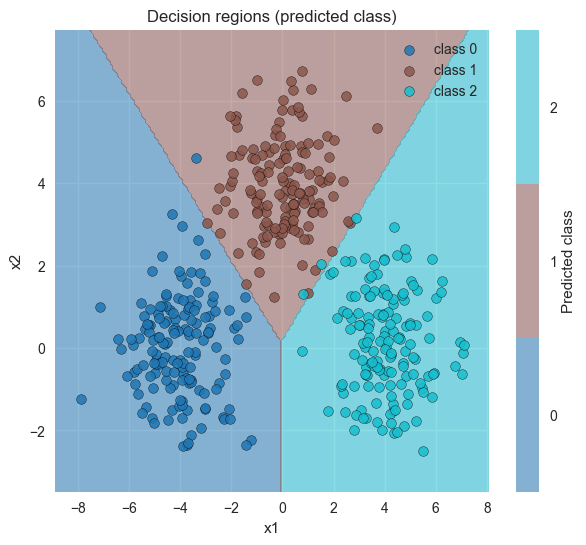

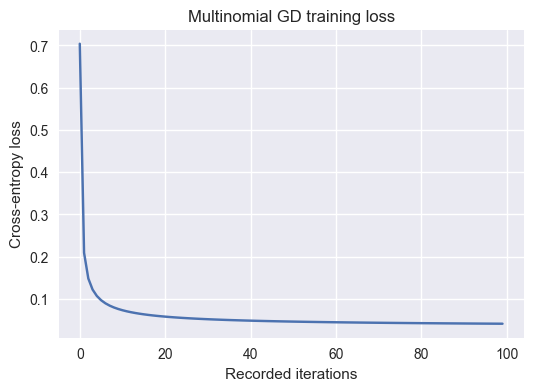

In [33]:
# Plot decision regions for GD solution
plot_decision_regions(B, X_multi, y_multi)

# Plot training loss curve
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(loss_hist)
plt.xlabel('Recorded iterations'); plt.ylabel('Cross-entropy loss'); plt.title('Multinomial GD training loss')
plt.grid(True); plt.show()

## Non-linear example: concentric circles (requires non-linear boundary)

This example uses a concentric-circle dataset (binary) to show that a linear logistic model cannot separate the classes, while a non-linear model (RBF SVM) can.

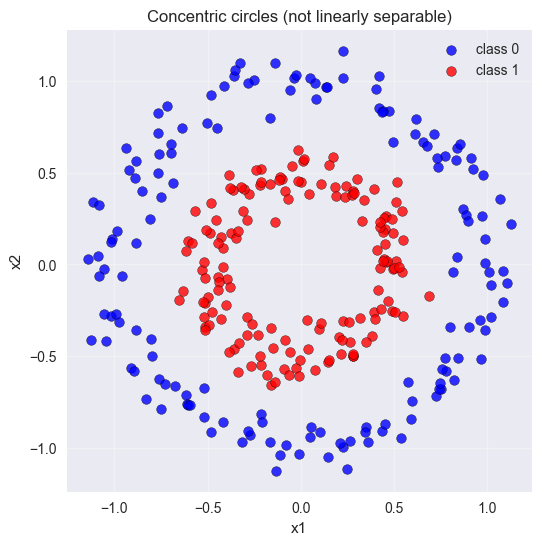

Logistic regression training accuracy: 0.5033333333333333


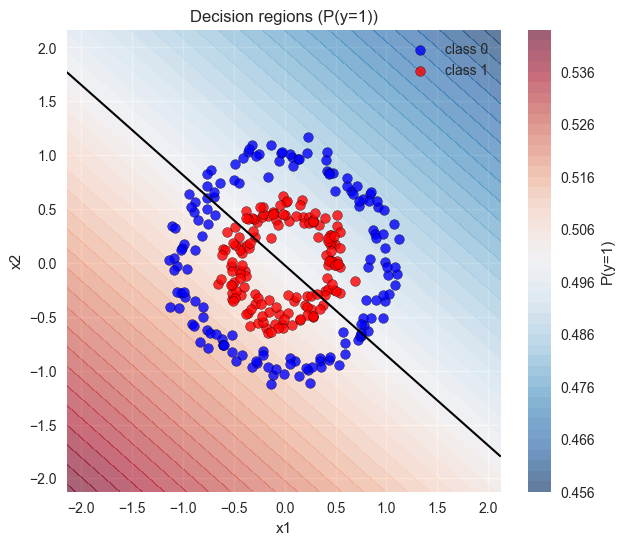

RBF SVM training accuracy: 1.0


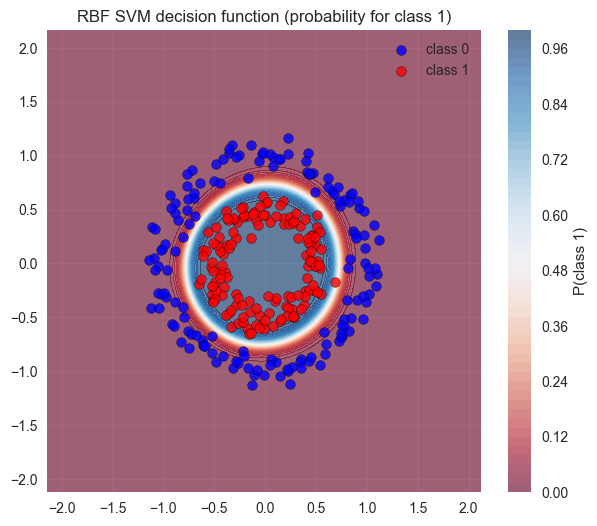

In [34]:
from sklearn.datasets import make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

# Create non-linearly separable dataset (concentric circles)
X_nl, y_nl = make_circles(n_samples=300, factor=0.5, noise=0.08, random_state=0)

plt.figure(figsize=(6,6))
plt.scatter(X_nl[y_nl==0,0], X_nl[y_nl==0,1], color='blue', label='class 0', edgecolor='k', alpha=0.8)
plt.scatter(X_nl[y_nl==1,0], X_nl[y_nl==1,1], color='red', label='class 1', edgecolor='k', alpha=0.8)
plt.title('Concentric circles (not linearly separable)')
plt.xlabel('x1'); plt.ylabel('x2')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Fit linear logistic regression
clf_lin = LogisticRegression()
clf_lin.fit(X_nl, y_nl)
beta_lin = np.hstack((clf_lin.intercept_, clf_lin.coef_.ravel()))
print('Logistic regression training accuracy:', clf_lin.score(X_nl, y_nl))

# Visualize linear decision boundary (will be linear and fail to separate concentric classes)
plot_decision_regions(beta_lin, X_nl, y_nl)

# For contrast: fit an RBF SVM to show non-linear boundary
clf_svc = SVC(kernel='rbf', probability=True)
clf_svc.fit(X_nl, y_nl)
print('RBF SVM training accuracy:', clf_svc.score(X_nl, y_nl))

# Decision surface for SVM (probability for class 1)
x_min, x_max = X_nl[:,0].min()-1, X_nl[:,0].max()+1
y_min, y_max = X_nl[:,1].min()-1, X_nl[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.column_stack((xx.ravel(), yy.ravel()))
Z = clf_svc.predict_proba(grid)[:,1].reshape(xx.shape)

plt.figure(figsize=(7,6))
cf = plt.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.6)
plt.scatter(X_nl[y_nl==0,0], X_nl[y_nl==0,1], color='blue', edgecolor='k', label='class 0', alpha=0.8)
plt.scatter(X_nl[y_nl==1,0], X_nl[y_nl==1,1], color='red', edgecolor='k', label='class 1', alpha=0.8)
plt.title('RBF SVM decision function (probability for class 1)')
cbar = plt.colorbar(cf); cbar.set_label('P(class 1)')
plt.legend(); plt.show()

### Exercise: try transforming the inputs

Consider applying a feature transform before fitting logistic regression. A suitable transform will map the original 2D inputs into new features that capture the geometric structure of the classes (for example, features that depend on radius or low-degree polynomials). Implement a transform function, re-fit logistic regression on the transformed features, and visualize the probability contour in the original 2D plane.

In [40]:
# Reference solution (radial transform)

def feature_transform(X):
    """Map 2D inputs to a small set of features that make concentric circles linearly separable.

    The transform used here adds the squared radius as an extra feature: r = x1**2 + x2**2.
    Returning [x1, x2, r] keeps the original coordinates for convenience and lets a linear
    model learn a radial decision boundary.

    Parameters
    ----------
    X : ndarray, shape (n_samples, 2)
        Original 2D inputs.

    Returns
    -------
    X_trans : ndarray, shape (n_samples, 3)
        Transformed features: [x1, x2, r].
    """
    X = np.asarray(X)
    x1 = X[:, 0]
    x2 = X[:, 1]
    r = x1**2 + x2**2
    return np.column_stack((x1, x2, r))


# Demonstration: fit logistic regression on transformed features and visualize usign our implementation of decision region plotting and logistic regression (not using sklearn for this part to show the full pipeline with our code)
X_trans = feature_transform(X_nl)
beta_trans, loss_hist_trans = fit_logistic_regression_gd(X_trans, y_nl, learning_rate=0.1, n_steps=1000)
print('Logistic regression on transformed features training accuracy:', np.mean((sigmoid(np.hstack((np.ones((X_trans.shape[0], 1)), X_trans)).dot(beta_trans)) >= 0.5) == y_nl))


Logistic regression on transformed features training accuracy: 1.0


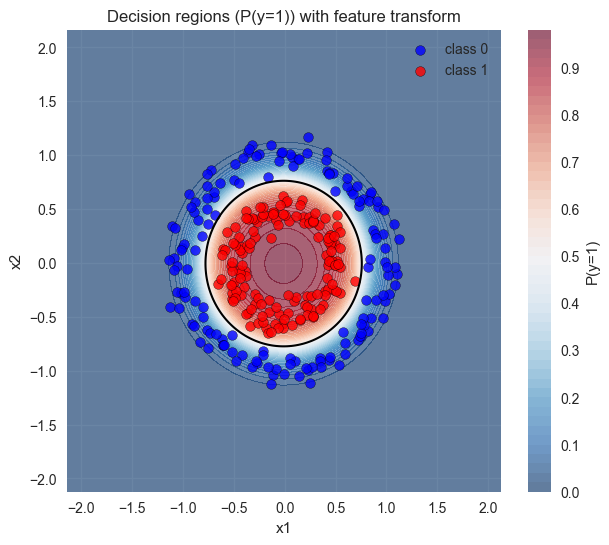

In [41]:


# To visualize decision regions, we need to apply the same feature transform to the grid points
def plot_decision_regions_transformed(params, X, y, grid_res=200, cmap='RdBu_r', proba_contours=[0.5], ax=None, show_prob=True):
    """Plot decision regions for logistic regression on transformed features.

    This function applies the same feature transform to the grid points before computing probabilities.

    Parameters
    ----------
    params : array-like, shape (d+1,)
        Parameter vector (intercept first) for logistic regression on transformed features.
    X : ndarray, shape (n_samples, 2)
        Original 2D input features (not transformed).
    y : ndarray, shape (n_samples,)
        Binary labels (0 or 1).
    grid_res : int, default=200
        Resolution of the evaluation grid.
    cmap : str, default='RdBu_r'
        Colormap for probability field.
    proba_contours : list, default=[0.5]
        Probability levels to draw contour lines for.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on. If None, a new figure/axes will be created.
    show_prob : bool, default=True
        Whether to show probability heatmap and contours.
    """
    from scipy.special import expit as _sigmoid

    params = np.asarray(params)
    X = np.asarray(X)
    y = np.asarray(y).ravel()

    if X.ndim != 2 or X.shape[1] != 2:
        raise ValueError('plot_decision_regions_transformed supports only 2D input features (n_samples, 2)')

    x_min, x_max = X[:,0].min() - 1.0, X[:,0].max() + 1.0
    y_min, y_max = X[:,1].min() - 1.0, X[:,1].max() + 1.0

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_res),
                          np.linspace(y_min, y_max, grid_res))
    grid = np.column_stack((xx.ravel(), yy.ravel()))
    grid_trans = feature_transform(grid)  # Apply the same feature transform to the grid points
    X_design_grid = np.hstack((np.ones((grid_trans.shape[0], 1)), grid_trans))  # Add intercept to transformed features
    probs = _sigmoid(X_design_grid.dot(params))
    Z = probs.reshape(xx.shape)
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7,6))
        created_fig = True
    if show_prob:
        cf = ax.contourf(xx, yy, Z, levels=50, cmap=cmap, alpha=0.6)
        if proba_contours is not None and len(proba_contours) > 0:
            ax.contour(xx, yy, Z, levels=proba_contours, colors='k', linewidths=1.5)
        if created_fig:
            cbar = plt.colorbar(cf, ax=ax)
            cbar.set_label('P(y=1)')
    else:
        Z_bin = (Z >= 0.5).astype(int)
        cf = ax.contourf(xx, yy, Z_bin, levels=[-0.5, 0.5, 1.5], cmap=cmap, alpha=0.3)
    ax.scatter(X[y==0,0], X[y==0,1], color='blue', edgecolor='k', label='class 0', alpha=0.8)
    ax.scatter(X[y==1,0], X[y==1,1], color='red', edgecolor='k', label='class 1', alpha=0.8)
    ax.set_title('Decision regions (P(y=1)) with feature transform')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.legend()
    if created_fig:
        plt.show()
plot_decision_regions_transformed(beta_trans, X_nl, y_nl)